In [13]:
import statsmodels.api as sm
from matplotlib.lines import Line2D
from statsmodels.stats.outliers_influence import variance_inflation_factor
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

import sys
sys.path.append("..")
from src import *
sns.set_theme("paper", font_scale=1.8)

In [10]:
# 1s
df_x, df_y = read_dataset('original')

## Multicollinearity test using VIF

##### ℹ️ This notebook doesn't output any file

*np* and *ng* are strongly inversely correlated.

#### $$np\approx  -1.06\times ng + 165$$

Why "inversely"?

Think of the engine like a shared power source with two "users" — the rotor and the compressor:

When the rotor draws a lot of power (like adding load to an electric generator), there’s less left for the compressor. When the rotor draws little power, the compressor can "take more" of the engine's energy.

In [11]:
def calculate_vif(data):
    vif_df = data.assign(const=1)
    vif = []
    for i in range(vif_df.shape[1]):
        vif.append(variance_inflation_factor(vif_df.values, i))
        

    vif_data = pd.Series(vif, index=vif_df.columns)
    vif_data = vif_data[vif_data.index != "const"]
    cmap = plt.cm.inferno
    norm = Normalize(vmin=vif_data.min(), vmax=vif_data.max())
    fig, ax = plt.subplots(figsize=(22, 5), dpi=150)
    ax.fill_between([-0.5, len(vif_data) - 0.5], 0, 5, color="tab:blue", alpha=0.25)
    ax.fill_between([-0.5, len(vif_data) - 0.5], 5, 41, color="tab:red", alpha=0.25)
    sns.barplot(x=vif_data.index, y=vif_data, hue=vif_data, palette=cmap, legend=False, ax=ax)
    ax.add_line(Line2D([-0.5, len(vif_data) - 0.5], [5] * 2, linestyle="--", color="tab:blue", linewidth=2))
    ax.set_xticklabels(map(to_latex, vif_data.index), rotation=90)
    ax.set_xlabel("")
    ax.set_ylabel("VIF")
    
    # sm = ScalarMappable(norm=norm,cmap=cmap)
    # fig.colorbar(sm, ax=ax, pad=0.01)
    return vif_data

/tmp/ipykernel_18714/2185275840.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(map(to_latex, vif_data.index), rotation=90)


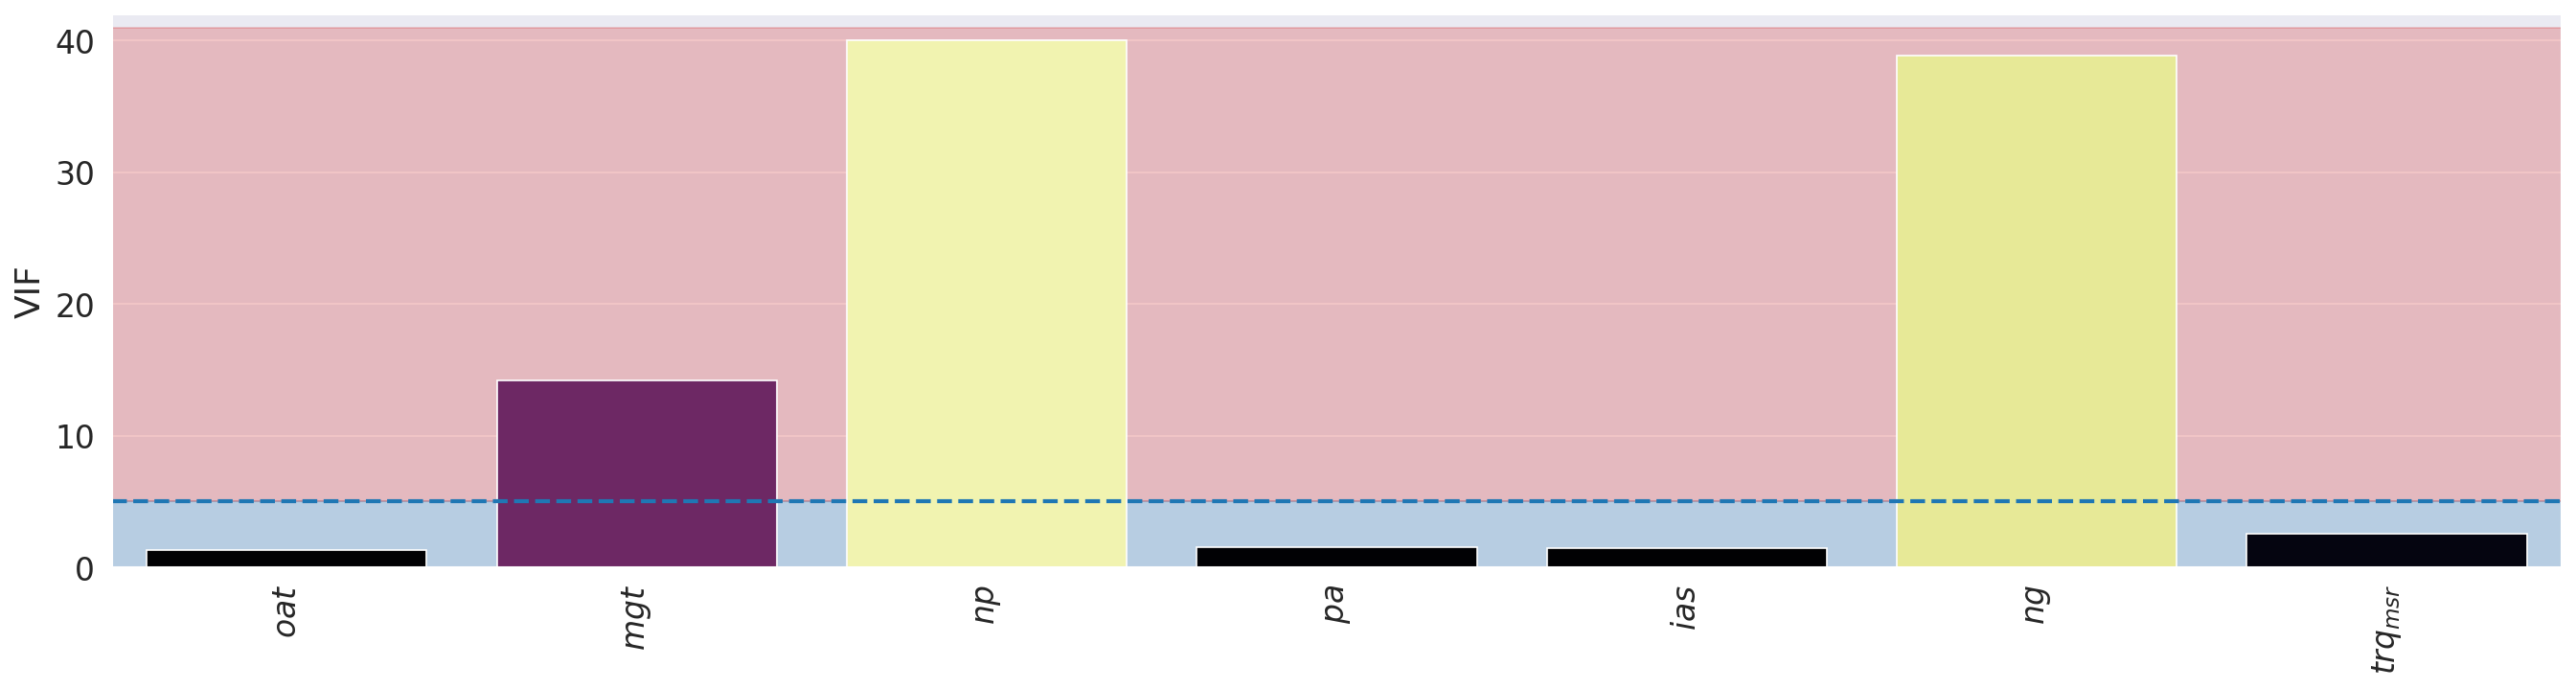

In [14]:
# 3s
vif_df = df_x[['oat', 'mgt', 'np', 'pa', 'ias', 'ng', 'trq_measured']]
vif_data = calculate_vif(vif_df)

Ok, there seems to be an interesting multicollinearity between the feature. What is the linear regressor that estimates np, with a good value of $R^2$?

In [15]:
# 0s
osl_x = vif_df.drop(columns=['np']).assign(const=1)
osl_y = df_x['np']
np_osl_model = sm.OLS(osl_y, osl_x).fit()
print(np_osl_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     np   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 4.831e+06
Date:                Tue, 20 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:22:32   Log-Likelihood:            -7.1261e+05
No. Observations:              742625   AIC:                         1.425e+06
Df Residuals:                  742618   BIC:                         1.425e+06
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
oat             -0.0006      0.000     -5.867   

What a surprise! We can predict `np` from all the other features using a linear ressor having $R^2 =0.975$!

In [31]:
np_pred

0      98.462122
1      89.624874
2     100.008763
3      90.638394
4      99.608905
5      96.442646
6      87.919181
7      98.716953
8     100.048845
9      95.731382
10     99.390724
11     91.481647
12     98.354046
13     99.349750
14    100.553224
15    100.342989
16     90.821096
17    100.023420
18    100.279473
19    100.684178
20     96.463760
21     89.374175
22     98.790858
23     95.692700
dtype: float64

(np.float64(-0.789165400451907), np.float64(8.13685802768789))

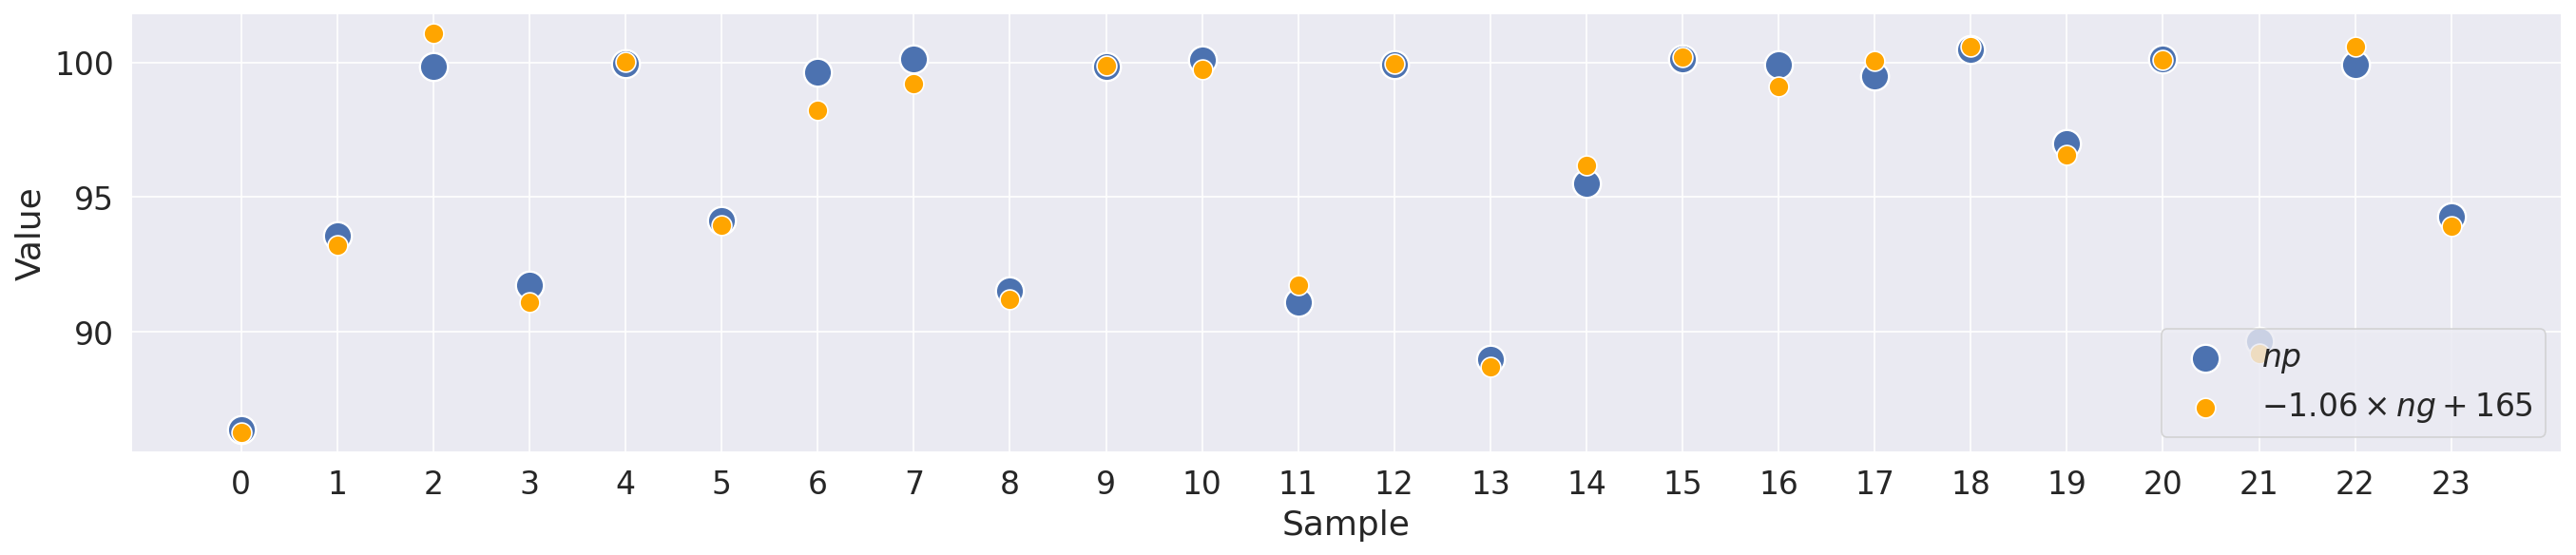

In [101]:
# 0s
LENGTH = 24
idx = random.randrange(len(df_x) - LENGTH)
np_pred = pd.Series(np_osl_model.predict()[idx : idx + LENGTH])
np_real = df_x["np"][idx : idx + LENGTH]
df = pd.DataFrame(
    {
        "index": range(LENGTH),
        "np_real": np_real.values,
        "np_pred": np_pred.values,
    }
)

plt.figure(figsize=(22, 4), dpi=150)
ax = sns.scatterplot(
    data=df,
    x="index",
    y="np_real",
    s=200,
    label="$np$",
)

sns.scatterplot(
    data=df,
    x="index",
    y="np_pred",
    s=100,
    color="orange",
    label="$-1.06\\times ng + 165$",
    ax=ax,
)
ax.legend(loc="lower right")
ax.set_xticks(df.index)
ax.set_ylabel("Value")
ax.set_xlabel("Sample")
# ax = ng_pred.plot(figsize=(20, 6), label='$-1.06\\times ng + 165$', linewidth=2, kind='scatter')
# (df_x['np'][:100]).plot(ax=ax, label='$np$', kind='scatter')
df_x["ng"].corr(df_x["np"]), ((np_pred.values - np_real.values) ** 2).sum()

The prediction is very accurate.

The correlation between `np` and `ng` is only $-0.79$, which is not enough for a later pruning to remove one of them. In other words, without this multicollinearity study, *we would have ended up feeding our models with an almost irrelevant feature*.